In [1]:
import joblib
import pandas as pd

# Load the trained final model
model = joblib.load("../04_models/random_forest_model.pkl")

# Load the scaler
scaler = joblib.load("../04_models/scaler.pkl")

print("Final model and scaler loaded successfully.")

Final model and scaler loaded successfully.


In [2]:
# List of the 21 CTG input features

feature_names = [
    "baseline value",
    "accelerations",
    "fetal_movement",
    "uterine_contractions",
    "light_decelerations",
    "severe_decelerations",
    "prolongued_decelerations",
    "abnormal_short_term_variability",
    "mean_value_of_short_term_variability",
    "percentage_of_time_with_abnormal_long_term_variability",
    "mean_value_of_long_term_variability",
    "histogram_width",
    "histogram_min",
    "histogram_max",
    "histogram_number_of_peaks",
    "histogram_number_of_zeroes",
    "histogram_mode",
    "histogram_mean",
    "histogram_median",
    "histogram_variance",
    "histogram_tendency"
]

print("Number of features:", len(feature_names))

Number of features: 21


In [3]:
# Enter the 21 CTG feature values

input_values = [
    132,      # baseline value
    0.006,    # accelerations
    0.0,      # fetal_movement
    0.006,    # uterine_contractions
    0.003,    # light_decelerations
    0.0,      # severe_decelerations
    0.0,      # prolongued_decelerations
    17,       # abnormal_short_term_variability
    2.1,      # mean_value_of_short_term_variability
    0.0,      # percentage_of_time_with_abnormal_long_term_variability
    10.4,     # mean_value_of_long_term_variability
    130,      # histogram_width
    68,       # histogram_min
    198,      # histogram_max
    6,        # histogram_number_of_peaks
    1,        # histogram_number_of_zeroes
    141,      # histogram_mode
    136,      # histogram_mean
    140,      # histogram_median
    12,       # histogram_variance
    0         # histogram_tendency
]

print("Number of input values:", len(input_values))

Number of input values: 21


In [4]:
input_df = pd.DataFrame(
    [input_values],
    columns=feature_names
)

print("Input DataFrame created successfully.")
print(input_df)

Input DataFrame created successfully.
   baseline value  accelerations  fetal_movement  uterine_contractions  \
0             132          0.006             0.0                 0.006   

   light_decelerations  severe_decelerations  prolongued_decelerations  \
0                0.003                   0.0                       0.0   

   abnormal_short_term_variability  mean_value_of_short_term_variability  \
0                               17                                   2.1   

   percentage_of_time_with_abnormal_long_term_variability  ...  \
0                                                0.0       ...   

   histogram_width  histogram_min  histogram_max  histogram_number_of_peaks  \
0              130             68            198                          6   

   histogram_number_of_zeroes  histogram_mode  histogram_mean  \
0                           1             141             136   

   histogram_median  histogram_variance  histogram_tendency  
0               140       

In [5]:
# Scale the manual input using the saved scaler

input_scaled = scaler.transform(input_df)

print("Input scaled successfully.")
print(input_scaled)

Input scaled successfully.
[[-0.13756224  0.72477418 -0.20254805  0.53415816  0.37567467 -0.06449217
  -0.27162618 -1.74393016  0.86556387 -0.54795423  0.41345023  1.55682309
  -0.89080382  1.91124879  0.67520093  0.96615833  0.21524358  0.08150551
   0.12836262 -0.23216898 -0.50480156]]


In [6]:
# Make the fetal health prediction

prediction = model.predict(input_scaled)

print("Predicted Class:", prediction[0])

Predicted Class: 1.0


In [7]:
# Get prediction probabilities and confidence

probabilities = model.predict_proba(input_scaled)

confidence = max(probabilities[0]) * 100

print("Prediction Probabilities:")
print("Normal       :", round(probabilities[0][0] * 100, 2), "%")
print("Suspect      :", round(probabilities[0][1] * 100, 2), "%")
print("Pathological :", round(probabilities[0][2] * 100, 2), "%")

print("\nModel Confidence:", round(confidence, 2), "%")

Prediction Probabilities:
Normal       : 99.71 %
Suspect      : 0.27 %
Pathological : 0.02 %

Model Confidence: 99.71 %


In [8]:
# Generate the CDSS recommendation

if prediction[0] == 1:
    recommendation = "Normal: Continue routine fetal monitoring."

elif prediction[0] == 2:
    recommendation = "Suspect: Immediate clinical evaluation is recommended."

elif prediction[0] == 3:
    recommendation = "Pathological: Urgent clinical intervention is recommended."

print("CDSS Recommendation:")
print(recommendation)

CDSS Recommendation:
Normal: Continue routine fetal monitoring.


#### It proves that the Above saved Random Forest + saved scaler + manual input pipeline are connected and functioning correctly.

In [9]:
#RF feature importance
import matplotlib.pyplot as plt

feature_importance = model.feature_importances_

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": feature_importance
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

print(importance_df)

                                              Feature  Importance
8                mean_value_of_short_term_variability    0.154644
7                     abnormal_short_term_variability    0.119553
9   percentage_of_time_with_abnormal_long_term_var...    0.114625
17                                     histogram_mean    0.083087
6                            prolongued_decelerations    0.066139
16                                     histogram_mode    0.056412
1                                       accelerations    0.050236
18                                   histogram_median    0.048546
0                                      baseline value    0.043098
10                mean_value_of_long_term_variability    0.042360
3                                uterine_contractions    0.038617
12                                      histogram_min    0.033275
19                                 histogram_variance    0.033253
11                                    histogram_width    0.029462
13        

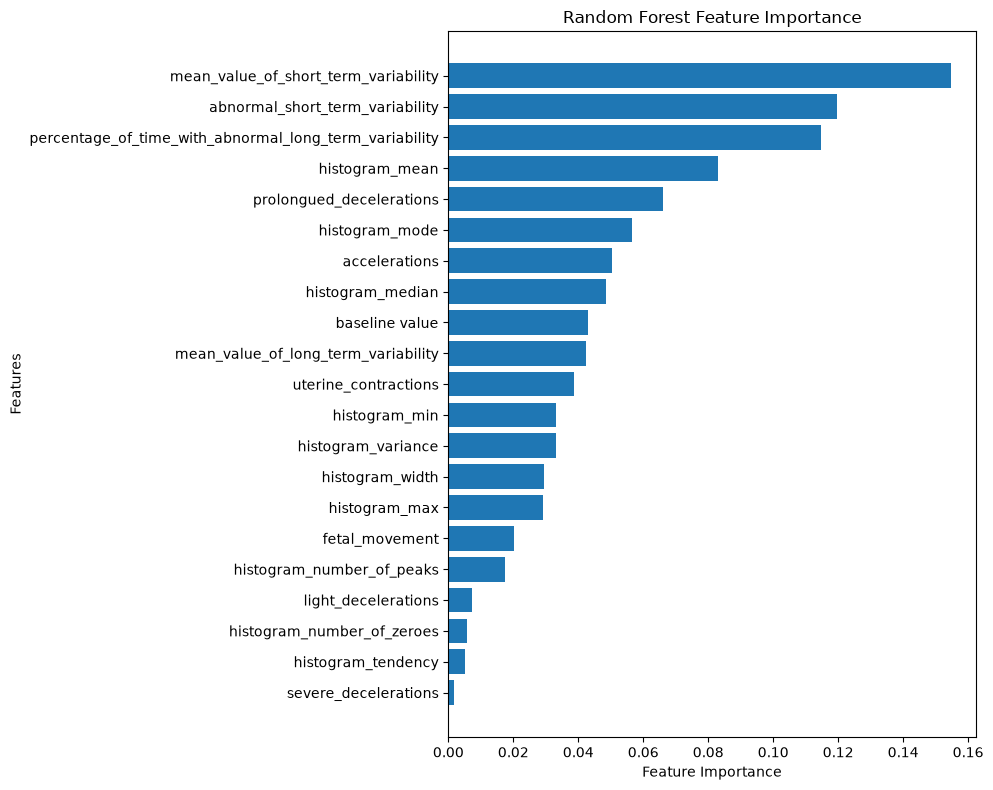

In [10]:
#feature importance plot/graph
plt.figure(figsize=(10, 8))

plt.barh(
    importance_df["Feature"],
    importance_df["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Features")
plt.title("Random Forest Feature Importance")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [11]:
# Save the feature importance results to a CSV file
importance_df.to_csv(
    "../05_results/random_forest_feature_importance.csv",
    index=False
)

print("Feature importance results saved successfully.")

Feature importance results saved successfully.


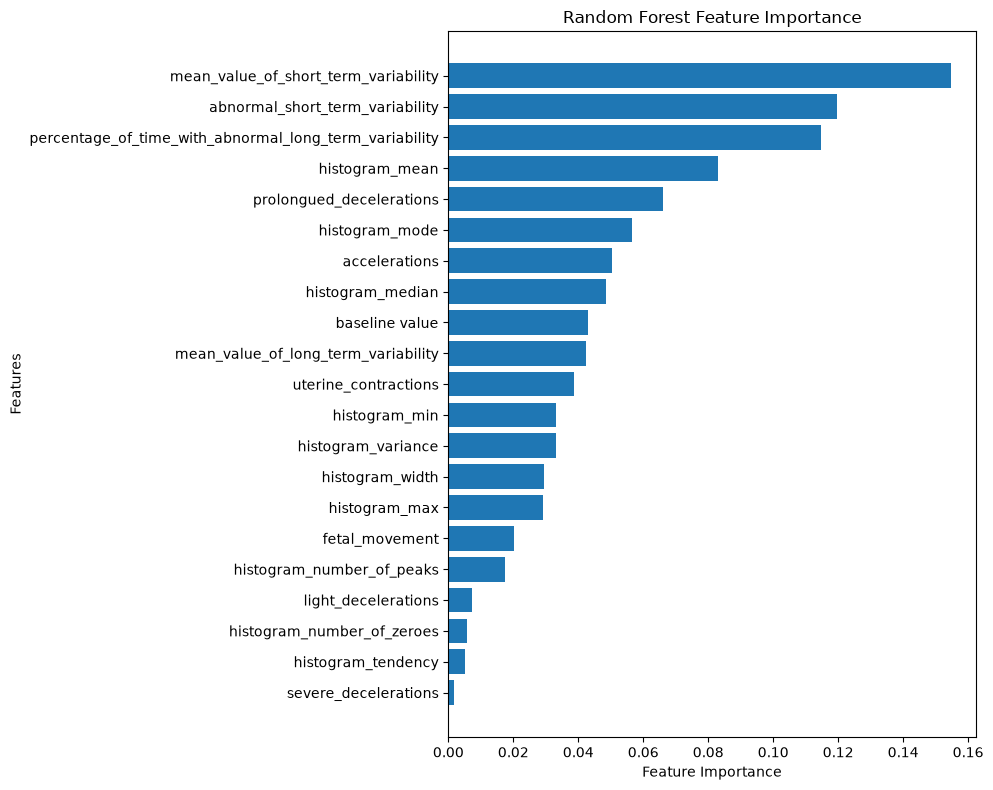

Feature importance graph saved successfully.


In [13]:
# Save the feature importance graph as an image
plt.figure(figsize=(10, 8))

plt.barh(
    importance_df["Feature"],
    importance_df["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Features")
plt.title("Random Forest Feature Importance")

plt.gca().invert_yaxis()
plt.tight_layout()

plt.savefig(
    "../07_images/random_forest_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Feature importance graph saved successfully.")